In [1]:
import numpy as np 
import pandas as pd

import scanpy as sc 
import anndata as ann 

from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
import umap 

In [2]:
import os 

# Start by reading the files from the results dir 
os.chdir('../../../results/control/integrated_results/')
results_files = os.listdir()

In [3]:
results_files

['pbmc_2_batch_base_balanced_1_celltypes_0_downsample_1_batch_ds_c_151_integrated_helical.h5ad',
 'pbmc_2_batch_base_balanced_1_celltypes_0_downsample_1_batch_ds_c_16_integrated_helical.h5ad',
 'pbmc_2_batch_base_balanced_1_celltypes_0_downsample_0_batch_ds_c_76_integrated_helical.h5ad',
 'pbmc_2_batch_hierarchical_balanced_1_celltypes_0.1_downsample_0_batch_ds_c_174_integrated_helical.h5ad',
 'pbmc_2_batch_hierarchical_balanced_1_celltypes_0.1_downsample_1_batch_ds_c_35_integrated_helical.h5ad',
 'pbmc_2_batch_hierarchical_balanced_1_celltypes_0_downsample_1_batch_ds_c_72_integrated_helical.h5ad',
 'pbmc_2_batch_hierarchical_balanced_1_celltypes_0.1_downsample_0_batch_ds_c_128_integrated_helical.h5ad',
 'pbmc_2_batch_base_balanced_1_celltypes_0_downsample_1_batch_ds_c_143_integrated_helical.h5ad',
 'pbmc_2_batch_hierarchical_balanced_1_celltypes_0.1_downsample_0_batch_ds_c_134_integrated_helical.h5ad',
 'pbmc_2_batch_base_balanced_1_celltypes_0_downsample_0_batch_ds_c_138_integrated_h

In [4]:
# Group files based on control, downsampled and ablated - 2 batch base balanced 

control_files = [f for f in results_files if '0_batch_ds' in f]
ds_files = [f for f in results_files if '1_celltypes_0.1_downsample_1_batch_ds' in f]
ablated_files = [f for f in results_files if '1_celltypes_0_downsample_1_batch_ds' in f]

In [6]:
control_files_base = [cf for cf in control_files if 'base' in cf]
ds_files_base = [dsf for dsf in ds_files if 'base' in dsf]
ablated_files_base = [af for af in ablated_files if 'base' in af]

In [12]:
# Randomly sample 3 control files, 3 downsampled files and 3 ablated files
control_files_sample = np.random.choice(control_files_base, 3, replace=False)
ds_files_sample = np.random.choice(ds_files_base, 3, replace=False)
ablated_files_sample = np.random.choice(ablated_files_base, 3, replace=False)

# Load the files into a list of adata objects
control_adata = [sc.read(f) for f in control_files_sample]
ds_adata = [sc.read(f) for f in ds_files_sample]
ablated_adata = [sc.read(f) for f in ablated_files_sample]

/home/hmaan/mambaforge/envs/citeseq_env/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/hmaan/mambaforge/envs/citeseq_env/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/hmaan/mambaforge/envs/citeseq_env/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/hmaan/mambaforge/envs/citeseq_env/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/hmaan/mambaforge/envs/citeseq_env/lib/python3.9/site-packages/anndata/

In [18]:
# Create a function that splits the anndatas into 3 anndatas based on the integration method 

def split_adata(adata):
    # Get the integration method from the obs attribute
    integration_method = adata.obs['integration_method'].values 
    
    # Subset the adata based on the integration method
    adata_uce = adata[integration_method == 'uce']
    adata_scgpt = adata[integration_method == 'scgpt']
    adata_geneformer = adata[integration_method == 'geneformer']
    
    return adata_uce, adata_scgpt, adata_geneformer

# Split the adata objects into 3 adata objects based on the integration method
control_adatas_uce = []
control_adatas_scgpt = []
control_adatas_geneformer = []

ds_adatas_uce = []
ds_adatas_scgpt = []
ds_adatas_geneformer = []

ablated_adatas_uce = []
ablated_adatas_scgpt = []
ablated_adatas_geneformer = []

# Loop through the control adata objects and split them
for adata in control_adata:
    adata_uce, adata_scgpt, adata_geneformer = split_adata(adata)
    control_adatas_uce.append(adata_uce)
    control_adatas_scgpt.append(adata_scgpt)
    control_adatas_geneformer.append(adata_geneformer)
    
for adata in ds_adata:
    adata_uce, adata_scgpt, adata_geneformer = split_adata(adata)
    ds_adatas_uce.append(adata_uce)
    ds_adatas_scgpt.append(adata_scgpt)
    ds_adatas_geneformer.append(adata_geneformer)
    
for adata in ablated_adata:
    adata_uce, adata_scgpt, adata_geneformer = split_adata(adata)
    ablated_adatas_uce.append(adata_uce)
    ablated_adatas_scgpt.append(adata_scgpt)
    ablated_adatas_geneformer.append(adata_geneformer)
    

/tmp/ipykernel_38975/1545951427.py:4: ImplicitModificationWarning: Removing element `.obsm['X_umap']` of view, initializing view as actual.
  del adata.obsm['X_umap']


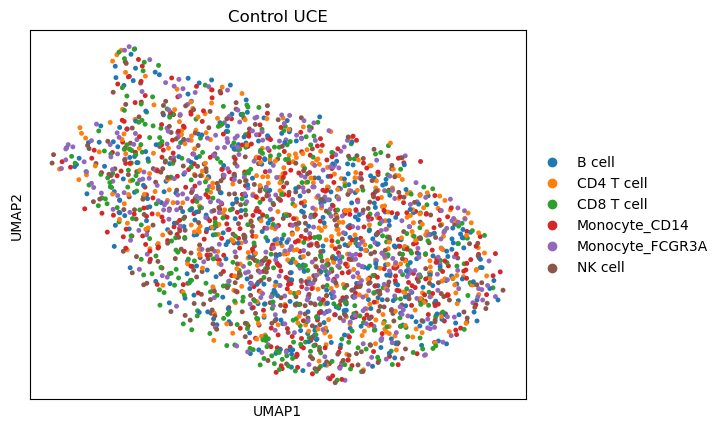

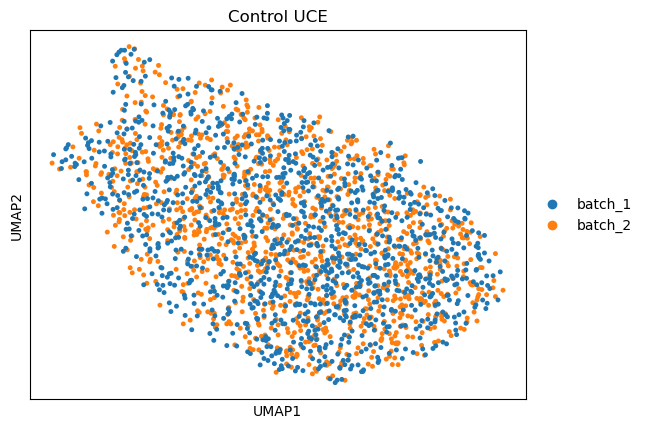

In [28]:
# Remove the old umap embeddings
for adata in control_adatas_uce:
    if 'X_umap' in adata.obsm.keys():
        del adata.obsm['X_umap']

# Visualize the first control experiment for UCE 
sc.pp.neighbors(control_adatas_uce[0], n_neighbors=15, use_rep='X_emb_reduced')
sc.tl.umap(control_adatas_uce[0])

# Plot the UMAP with the celltype and batch as color - increase width between the plots 
sc.pl.umap(control_adatas_uce[0], color=['celltype'], title='Control UCE', wspace=0.5)
sc.pl.umap(control_adatas_uce[0], color=['batch'], title='Control UCE', wspace=0.5)

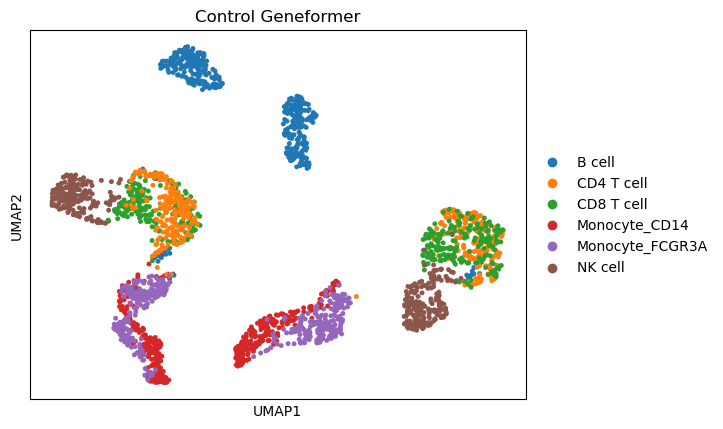

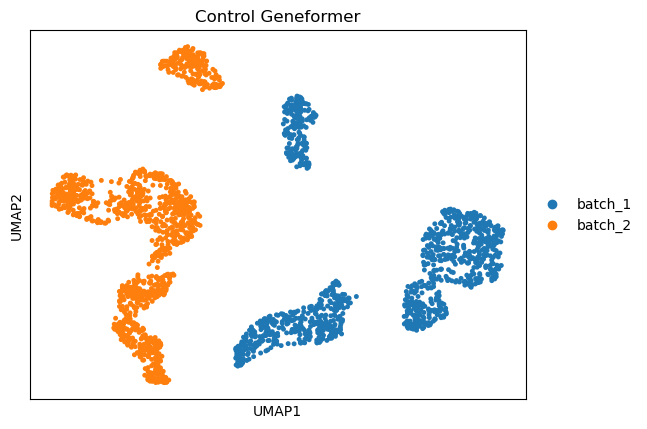

In [29]:
# Visualize the first control experiment Geneformer 
sc.pp.neighbors(control_adatas_geneformer[0], n_neighbors=15, use_rep='X_emb_reduced')
sc.tl.umap(control_adatas_geneformer[0])

# Plot the UMAP with the celltype and batch as color - increase width between the plots
sc.pl.umap(control_adatas_geneformer[0], color=['celltype'], title='Control Geneformer', wspace=0.5)
sc.pl.umap(control_adatas_geneformer[0], color=['batch'], title='Control Geneformer', wspace=0.5)

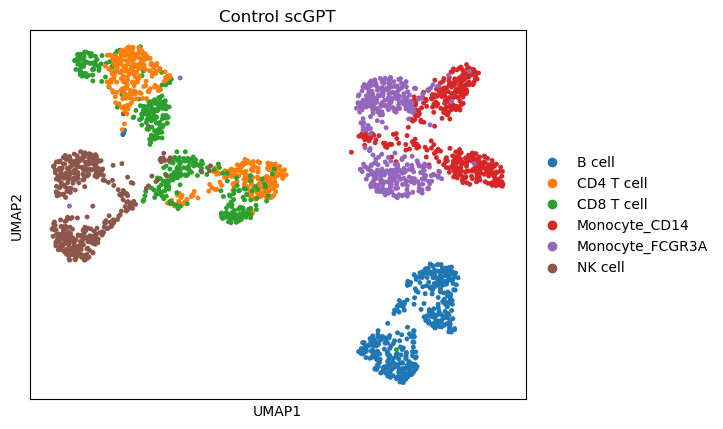

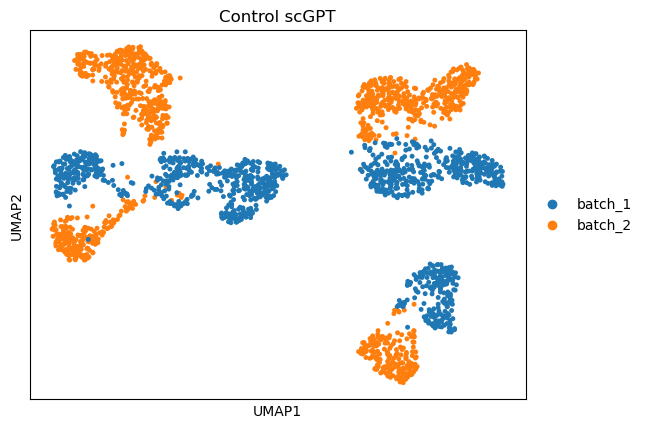

In [30]:
# Visualize the first control experiment scGPT
sc.pp.neighbors(control_adatas_scgpt[0], n_neighbors=15, use_rep='X_emb_reduced')
sc.tl.umap(control_adatas_scgpt[0])

# Plot the UMAP with the celltype and batch as color - increase width between the plots
sc.pl.umap(control_adatas_scgpt[0], color=['celltype'], title='Control scGPT', wspace=0.5)
sc.pl.umap(control_adatas_scgpt[0], color=['batch'], title='Control scGPT', wspace=0.5)

/tmp/ipykernel_38975/2091238698.py:6: ImplicitModificationWarning: Removing element `.obsm['X_umap']` of view, initializing view as actual.
  del adata.obsm['X_umap']


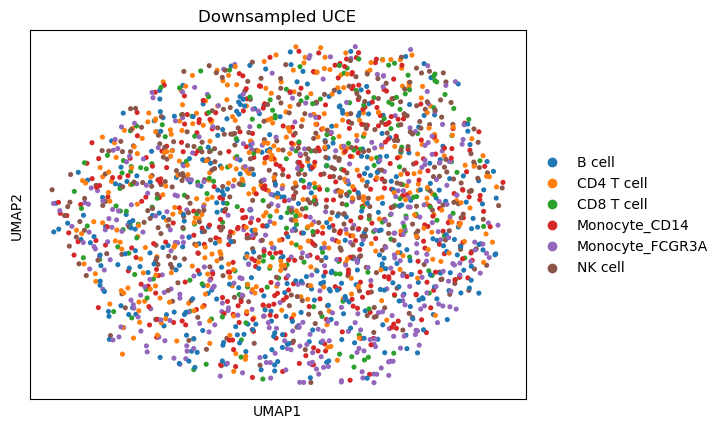

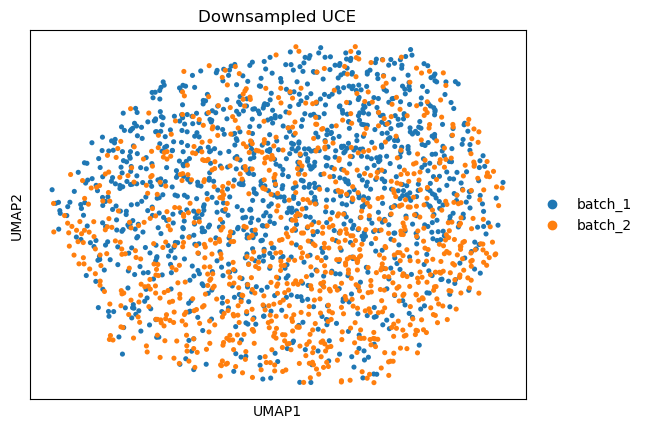

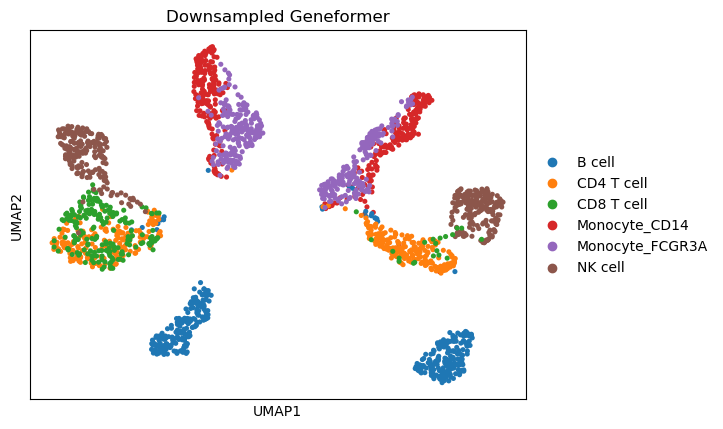

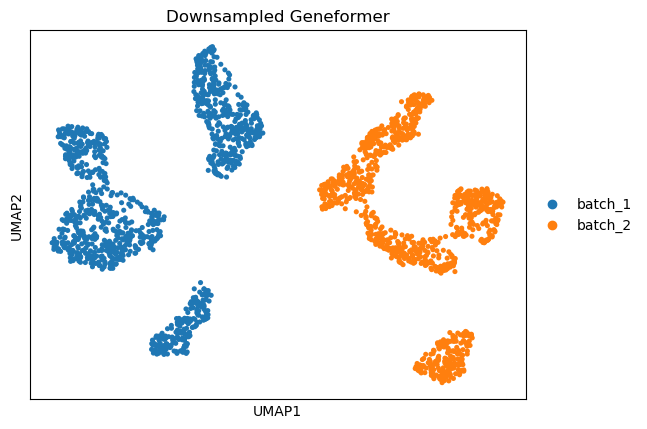

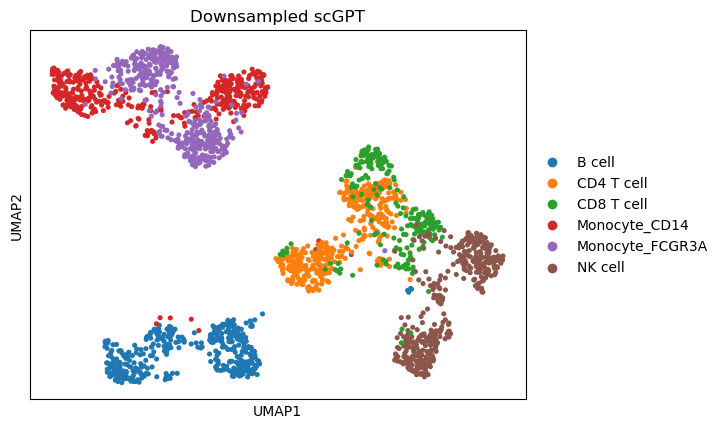

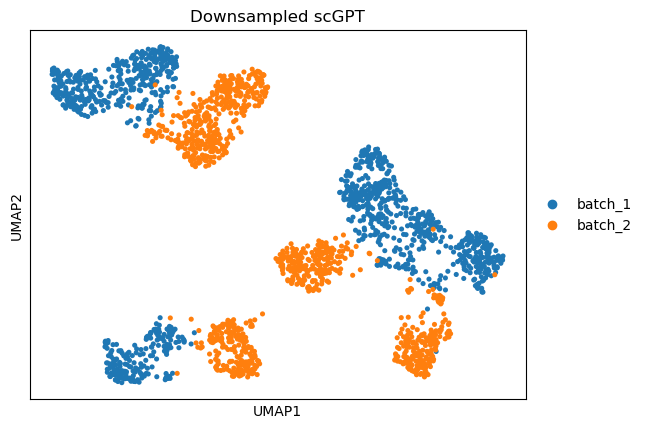

In [31]:
# Now we can visualize the downsampled data - for each integration method

# Remove the old umap embeddings
for adata in ds_adatas_uce:
    if 'X_umap' in adata.obsm.keys():
        del adata.obsm['X_umap']
        
# Visualize the first downsampled experiment for UCE
sc.pp.neighbors(ds_adatas_uce[0], n_neighbors=15, use_rep='X_emb_reduced')
sc.tl.umap(ds_adatas_uce[0])
# Plot the UMAP with the celltype and batch as color - increase width between the plots
sc.pl.umap(ds_adatas_uce[0], color=['celltype'], title='Downsampled UCE', wspace=0.5)
sc.pl.umap(ds_adatas_uce[0], color=['batch'], title='Downsampled UCE', wspace=0.5)


# Visualize the first downsampled experiment Geneformer
sc.pp.neighbors(ds_adatas_geneformer[0], n_neighbors=15, use_rep='X_emb_reduced')
sc.tl.umap(ds_adatas_geneformer[0])
# Plot the UMAP with the celltype and batch as color - increase width between the plots
sc.pl.umap(ds_adatas_geneformer[0], color=['celltype'], title='Downsampled Geneformer', wspace=0.5)
sc.pl.umap(ds_adatas_geneformer[0], color=['batch'], title='Downsampled Geneformer', wspace=0.5)

# Visualize the first downsampled experiment scGPT
sc.pp.neighbors(ds_adatas_scgpt[0], n_neighbors=15, use_rep='X_emb_reduced')
sc.tl.umap(ds_adatas_scgpt[0])
# Plot the UMAP with the celltype and batch as color - increase width between the plots
sc.pl.umap(ds_adatas_scgpt[0], color=['celltype'], title='Downsampled scGPT', wspace=0.5)
sc.pl.umap(ds_adatas_scgpt[0], color=['batch'], title='Downsampled scGPT', wspace=0.5)

In [34]:
# Function to return counts of celltypes in anndata, per batch

def get_counts(adata):
    # Get the counts of celltypes in the adata object
    counts = adata.obs['celltype'].value_counts()
    
    # Return the counts as a dataframe
    df = pd.DataFrame(counts)
    
    return df


In [35]:
# Count the number of celltypes in the first control experiment, first downsampled experiment and first ablated experiment

control_counts = get_counts(control_adatas_uce[0])
ds_counts = get_counts(ds_adatas_uce[0])
ablated_counts = get_counts(ablated_adatas_uce[0])

# Print the counts
print('Control counts:')
print(control_counts)
print('Downsampled counts:')
print(ds_counts)
print('Ablated counts:')
print(ablated_counts)

Control counts:
                 count
celltype              
B cell             400
CD4 T cell         400
CD8 T cell         400
Monocyte_CD14      400
Monocyte_FCGR3A    400
NK cell            400
Downsampled counts:
                 count
celltype              
B cell             400
CD4 T cell         400
Monocyte_CD14      400
Monocyte_FCGR3A    400
NK cell            400
CD8 T cell         220
Ablated counts:
                 count
celltype              
B cell             400
CD4 T cell         400
CD8 T cell         400
Monocyte_FCGR3A    400
NK cell            400
Monocyte_CD14      200


In [38]:
# Create a function to calculate ARI and AMI for cell-type conservation (bio signal) and batch-correction (technical signal)

def get_metrics(adata):
    # Perform leiden clustering using the embedding information 
    sc.pp.neighbors(adata, n_neighbors=15, use_rep='X_emb_reduced')
    sc.tl.leiden(adata, resolution=1.0)
    
    # Get the celltype and batch labels
    celltype_labels = adata.obs['celltype'].values
    batch_labels = adata.obs['batch'].values
    
    # Get the leiden labels
    leiden_labels = adata.obs['leiden'].values
    
    # Calculate the ARI and AMI for cell-type conservation
    ari_celltype = adjusted_rand_score(celltype_labels, leiden_labels)
    ami_celltype = adjusted_mutual_info_score(celltype_labels, leiden_labels)
    
    # Calculate the ARI and AMI for batch-correction
    ari_batch = 1 - adjusted_rand_score(batch_labels, leiden_labels)
    ami_batch = 1 - adjusted_mutual_info_score(batch_labels, leiden_labels)
    
    # Create a dictionary to store the metrics
    metrics = {
        'ari_celltype': ari_celltype,
        'ami_celltype': ami_celltype,
        'ari_batch': ari_batch,
        'ami_batch': ami_batch
    }
    
    return metrics

In [43]:
# Hacky within notebook installation of igraph 
%pip install igraph
%pip install leidenalg

Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 8.1 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [46]:
# Loop through and calculate the metrics for each of the adata objects - for UCE, scGPT and Geneformer

control_metrics_uce = []
control_metrics_scgpt = []
control_metrics_geneformer = []

ds_metrics_uce = []
ds_metrics_scgpt = []
ds_metrics_geneformer = []

ablated_metrics_uce = []
ablated_metrics_scgpt = []
ablated_metrics_geneformer = []

# Loop through the control adata objects and calculate the metrics
for adata in control_adatas_uce:
    metrics = get_metrics(adata)
    control_metrics_uce.append(metrics)
    
for adata in control_adatas_scgpt:
    metrics = get_metrics(adata)
    control_metrics_scgpt.append(metrics)
    
for adata in control_adatas_geneformer:
    metrics = get_metrics(adata)
    control_metrics_geneformer.append(metrics)
    
for adata in ds_adatas_uce:
    metrics = get_metrics(adata)
    ds_metrics_uce.append(metrics)
    
for adata in ds_adatas_scgpt:
    metrics = get_metrics(adata)
    ds_metrics_scgpt.append(metrics)
    
for adata in ds_adatas_geneformer:
    metrics = get_metrics(adata)
    ds_metrics_geneformer.append(metrics)
    
for adata in ablated_adatas_uce:
    metrics = get_metrics(adata)
    ablated_metrics_uce.append(metrics)
    
for adata in ablated_adatas_scgpt:
    metrics = get_metrics(adata)
    ablated_metrics_scgpt.append(metrics)
    
for adata in ablated_adatas_geneformer:
    metrics = get_metrics(adata)
    ablated_metrics_geneformer.append(metrics)
    
# Create a function to convert the metrics to a dataframe
def metrics_to_df(metrics, integration_method):
    # Create a dataframe from the metrics
    df = pd.DataFrame(metrics)
    
    # Add the integration method to the dataframe
    df['integration_method'] = integration_method
    
    return df

# Convert the metrics to dataframes
control_metrics_uce_df = metrics_to_df(control_metrics_uce, integration_method = 'uce')
control_metrics_scgpt_df = metrics_to_df(control_metrics_scgpt, integration_method = 'scgpt')
control_metrics_geneformer_df = metrics_to_df(control_metrics_geneformer, integration_method = 'geneformer')

ds_metrics_uce_df = metrics_to_df(ds_metrics_uce, integration_method = 'uce')
ds_metrics_scgpt_df = metrics_to_df(ds_metrics_scgpt, integration_method = 'scgpt')
ds_metrics_geneformer_df = metrics_to_df(ds_metrics_geneformer, integration_method = 'geneformer')

ablated_metrics_uce_df = metrics_to_df(ablated_metrics_uce, integration_method = 'uce')
ablated_metrics_scgpt_df = metrics_to_df(ablated_metrics_scgpt, integration_method = 'scgpt')
ablated_metrics_geneformer_df = metrics_to_df(ablated_metrics_geneformer, integration_method = 'geneformer')

# Add control, downsample, ablated info to the metrics dataframes
control_metrics_uce_df['experiment_type'] = 'control'
control_metrics_scgpt_df['experiment_type'] = 'control'
control_metrics_geneformer_df['experiment_type'] = 'control'

ds_metrics_uce_df['experiment_type'] = 'downsampled'
ds_metrics_scgpt_df['experiment_type'] = 'downsampled'
ds_metrics_geneformer_df['experiment_type'] = 'downsampled'

ablated_metrics_uce_df['experiment_type'] = 'ablated'
ablated_metrics_scgpt_df['experiment_type'] = 'ablated'
ablated_metrics_geneformer_df['experiment_type'] = 'ablated'

# Concatenate the dataframes
metrics_df = pd.concat([control_metrics_uce_df, control_metrics_scgpt_df, control_metrics_geneformer_df,
                         ds_metrics_uce_df, ds_metrics_scgpt_df, ds_metrics_geneformer_df,
                         ablated_metrics_uce_df, ablated_metrics_scgpt_df, ablated_metrics_geneformer_df], axis=0)

In [47]:
metrics_df

,ari_celltype,ami_celltype,ari_batch,ami_batch,integration_method,experiment_type
0,0.001627,0.003141,1.000408,1.000498,uce,control
1,0.002440,0.004545,0.991370,0.986756,uce,control
2,0.002713,0.005214,0.997056,0.996543,uce,control
0,0.468284,0.686179,0.861793,0.626536,scgpt,control
1,0.468881,0.687387,0.862165,0.626927,scgpt,control
2,0.468881,0.687387,0.862165,0.626927,scgpt,control
0,0.343012,0.574984,0.866401,0.599307,geneformer,control
1,0.343012,0.574984,0.866401,0.599307,geneformer,control
2,0.343012,0.574984,0.866401,0.599307,geneformer,control
0,0.005769,0.008987,0.986576,0.980146,uce,downsampled
